In [2]:
!pip install tensorflow

In [3]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input


STEP 1

In [4]:
#1.1, 1,2, 1.3
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# 1.4
print('Number of features:', len(df.columns))
print('Number of samples:', len(df))
print('Number of classes:', len(cancer.target_names))


Number of features: 30
Number of samples: 569
Number of classes: 2


In [6]:
#1.5 
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


1.6: This is a binary classification problem and its to predict whether or not there is a breast tumor or not, x values will be the 30 features and  target will be malignant or benign

STEP 2

In [8]:
df.isnull().sum() # 2.1 no null values

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [9]:
df.duplicated().sum() # 2.2 no duplicated values

np.int64(0)

In [10]:
df.info() #2.3 2.4 all features are numerical 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [11]:
target_count = df['target'].value_counts() # 2.5
print(target_count)

target
1    357
0    212
Name: count, dtype: int64


In [12]:
# 2.6 no problems exist from what I have seen

In [13]:
df.shape # 2.7 shape of the dataset is (569, 31) 

(569, 31)

PART 3

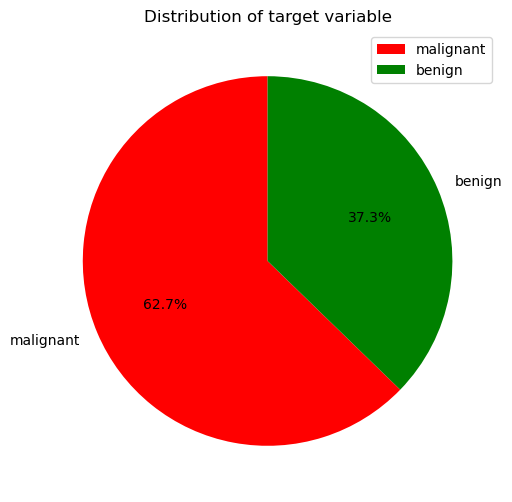

In [14]:
# class distribution 3.1 
plt.figure(figsize=(6,6))
plt.pie(target_count, labels=cancer.target_names, colors=['red', 'green'], startangle=90, autopct='%1.1f%%')
plt.legend()
plt.title('Distribution of target variable')
plt.show()


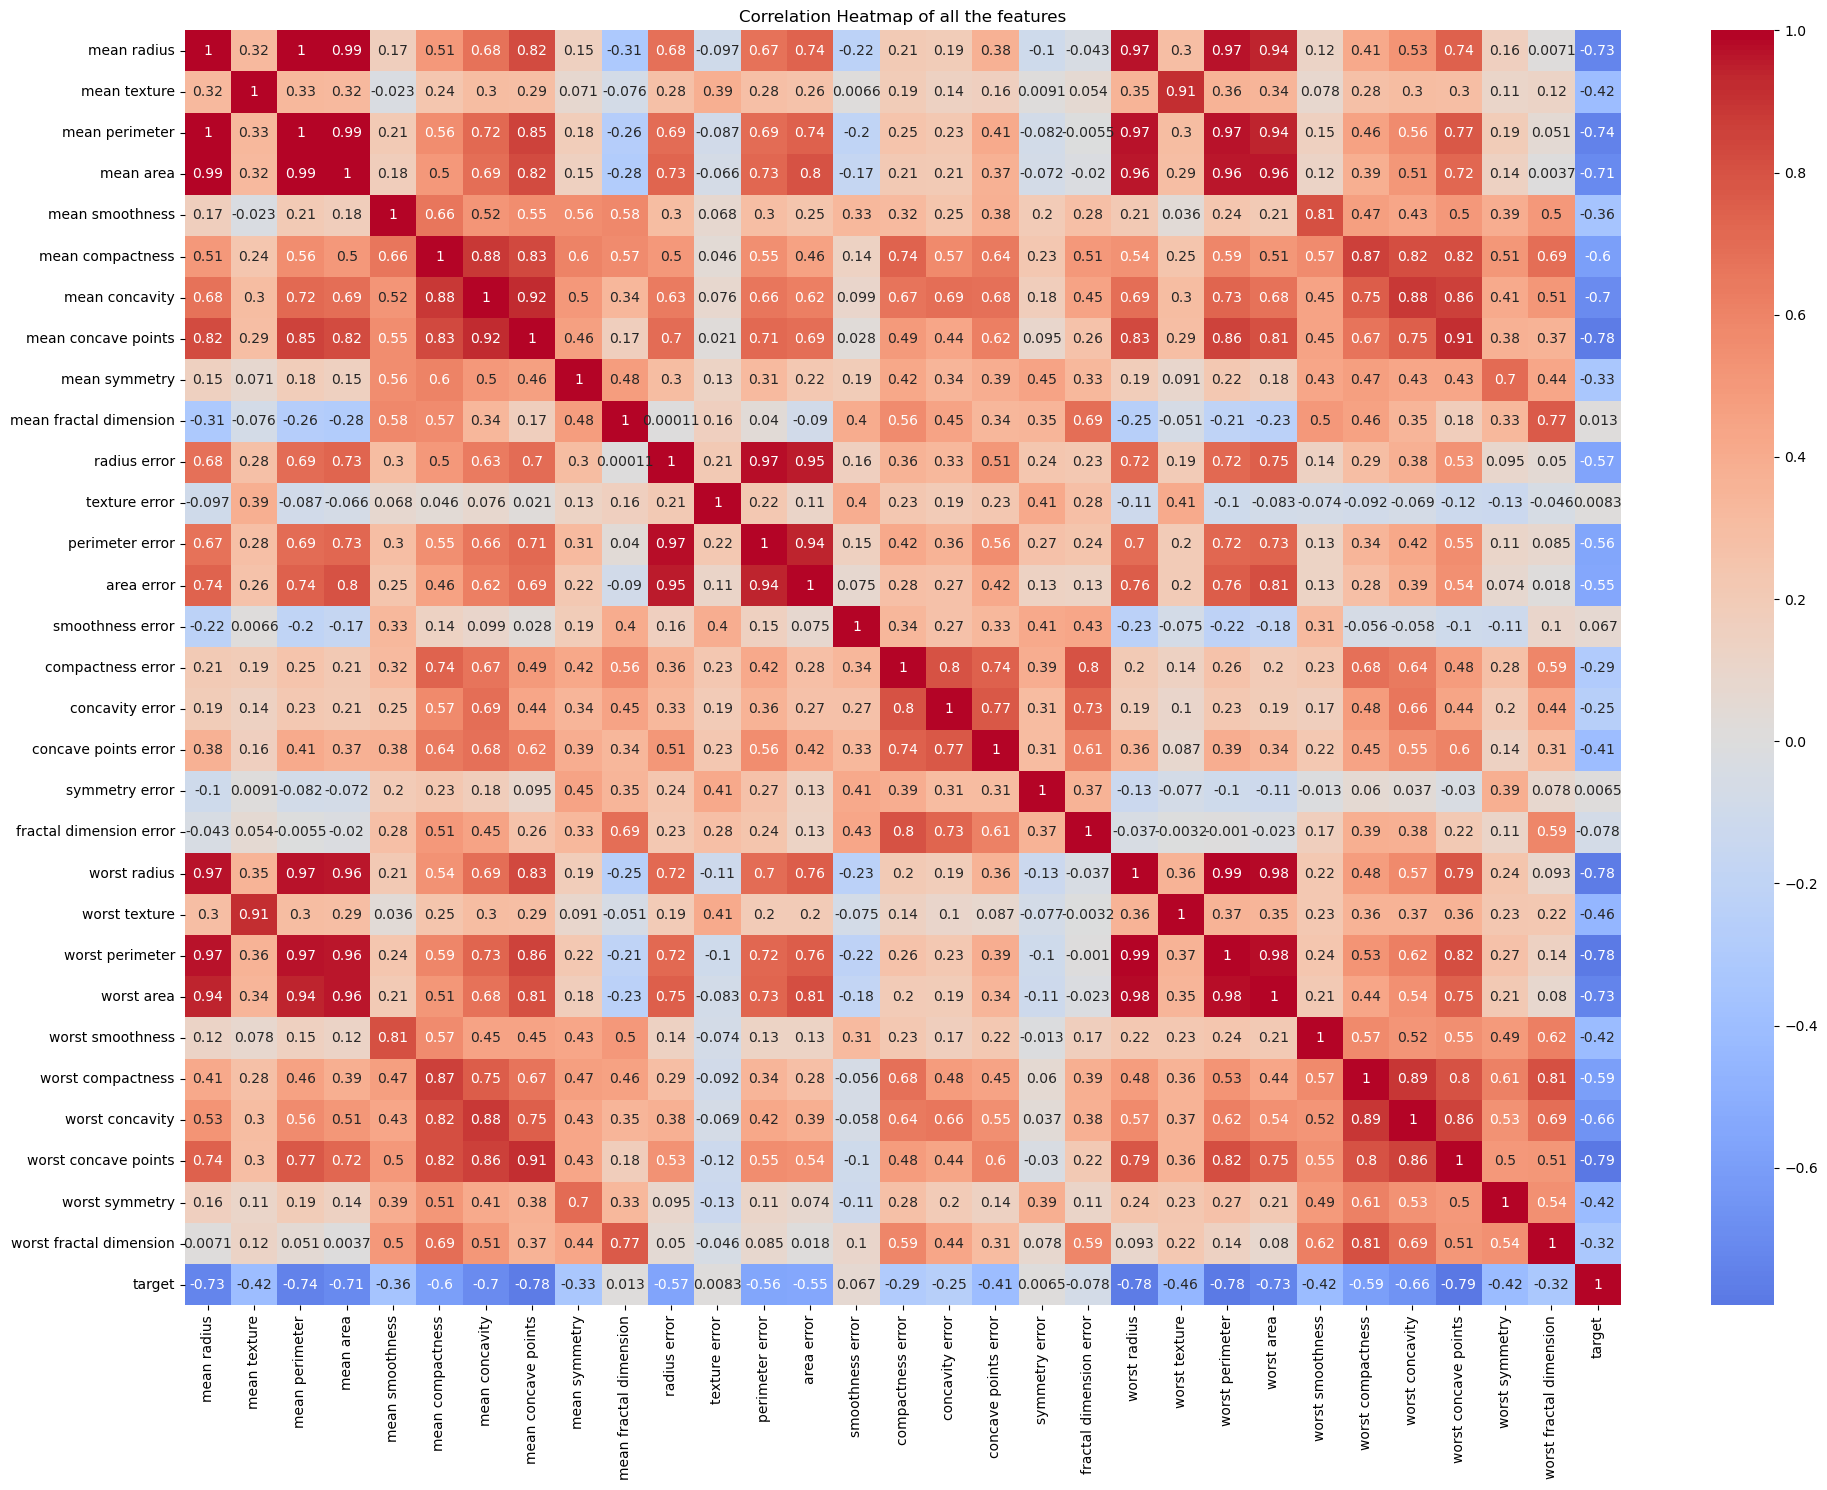

In [15]:
# heatmap of the correlation between the features 3.2
plt.figure(figsize=(20,15))
plt.title('Correlation Heatmap of all the features')
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

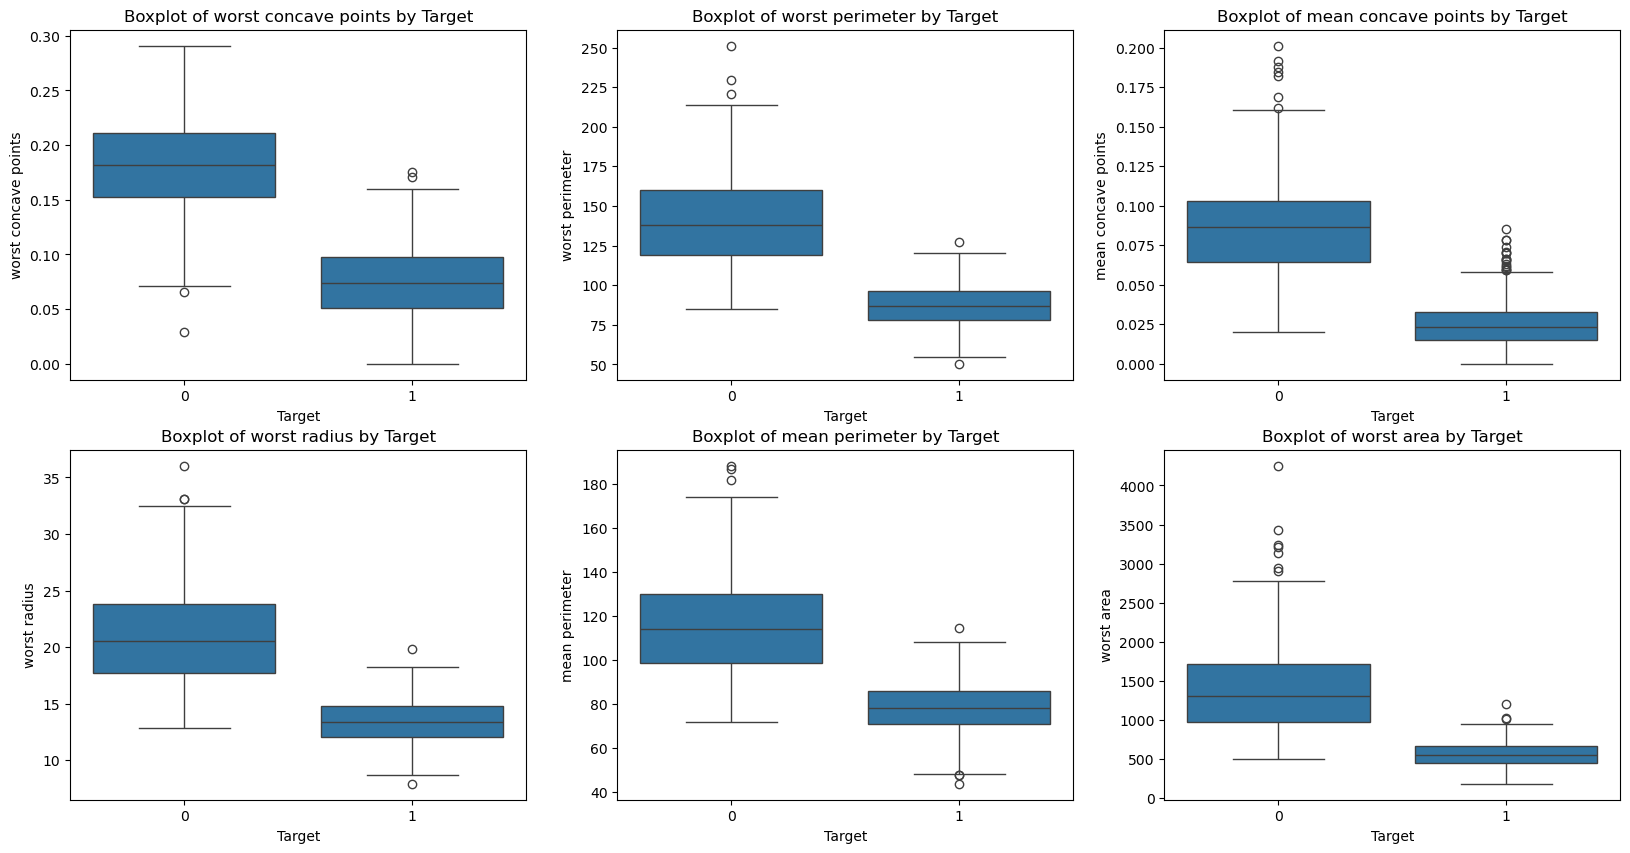

In [16]:
top = df.corr()['target'].abs().sort_values(ascending=False) 
top_features = top[1:7].index


fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x='target', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} by Target')
    axes[i].set_xlabel('Target')
    axes[i].set_ylabel(feature)


In [ ]:
for i, f in enumerate(top_features):
    sns.histplot(data=df, x=f, hue='target', kde=True, ax=axes.flatten()[i])
    axes[i].set_title(f'Histogram of {f} by Target')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
plt.tight_layout()
plt.show()

# i dont know how to do this part 3.4

C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_27164\3856521416.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_27164\3856521416.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_27164\3856521416.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_27164\3856521416.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is 

<Figure size 640x480 with 0 Axes>

PART 4

In [18]:
X = df.drop('target', axis=1)
y = df['target']

# X.info() no categorical data

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR)))

outliers_count = outliers.sum().sum()
outliers_count # im going to keep the outliers because this is medical data and outliers can be important in this case

np.int64(608)

PART 5

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Shape of training data {X_train.shape} \nShape of testing data {X_test.shape}')

Shape of training data (455, 30) 
Shape of testing data (114, 30)


PART 6

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


PART 7

In [21]:
model = Sequential()

# input layer
model.add(Flatten(input_shape=(30,)))

# hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.25))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.25))

# output layer
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


PART 8

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
    )

train_data = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    callbacks=[earlystop],
    epochs=20,
    batch_size=64
)

train_data.history['loss']
model.summary()

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9934 - loss: 0.0285 - val_accuracy: 0.9561 - val_loss: 0.0978
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.0266 - val_accuracy: 0.9561 - val_loss: 0.1044
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9934 - loss: 0.0259 - val_accuracy: 0.9561 - val_loss: 0.1102
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9561 - val_loss: 0.1137
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9956 - loss: 0.0189 - val_accuracy: 0.9561 - val_loss: 0.1093
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9912 - loss: 0.0243 - val_accuracy: 0.9561 - val_loss: 0.1130
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.0182 - val_accuracy: 0.9386 - val_loss: 0.1801
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9868 - loss: 0.0336 - val_accuracy: 0.9474 - val_loss: 0.1707


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,013 (168.02 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,676 (112.02 KB)

PART 9

In [50]:
y_pred_train = (model.predict(X_train_scaled) >0.5).astype(int)
y_pred_test = (model.predict(X_test_scaled) >0.5).astype(int)

# 1 training data 
print(f'The acuracy score of training data is: {round(accuracy_score(y_train, y_pred_train),5)}\n')

# 2 testing data
print(f'The acuracy score of testing data is: {round(accuracy_score(y_test, y_pred_test),5)}\n')


# 3 confusion matrix
print(f'Confusion Matrix for testing data:\n{confusion_matrix(y_test, y_pred_test)}\n')

# 4 precision
print(f'Precision for testing data: {round(precision_score(y_test, y_pred_test),5)}\n')

# 5 recall
print(f'Recall for testing data: {round(recall_score(y_test, y_pred_test),5)}\n')

# 6 f1 score
print(f'F1 Score for testing data: {round(f1_score(y_test, y_pred_test),5)}\n')

# 7 classification report
print(f'Classification Report for testing data:\n{classification_report(y_test, y_pred_test)}')
# there is no over or under fitting in the data as difference between accuracy score and val score 0.9912 and 0.9737 is 1.75% which is a good score and the model is generalizing well on the testing data

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
The acuracy score of training data is: 0.99341

The acuracy score of testing data is: 0.95614

Confusion Matrix for testing data:
[[41  1]
 [ 4 68]]

Precision for testing data: 0.98551

Recall for testing data: 0.94444

F1 Score for testing data: 0.96454

Classification Report for testing data:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



PART 10

In [62]:
from tensorflow.keras.layers import BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop


model2 = Sequential()

model2.add(Flatten(input_shape=(30,)))
# 2 hidden layers instead of 3 hidden layers  
model2.add(Dense(128, activation='tanh')) # different activation function
model2.add(BatchNormalization()) #different regularization technique instead of dropout
model2.add(Dense(64, activation='tanh'))
model2.add(BatchNormalization())

model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    loss='binary_crossentropy',
    metrics=['accuracy'],
    optimizer=RMSprop(learning_rate=0.005) # different optimizer and learning rate
)

model2.summary()


earlystrop2 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

train_data_2 = model2.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    callbacks=[earlystrop2],
    epochs=30, # change epochs 
    batch_size=64
    )

y_pred_train2 = (model2.predict(X_train_scaled)>0.5).astype(int)
y_pred_test2 = (model2.predict(X_test_scaled)>0.5).astype(int)



c:\Users\Ahmed Wael\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8857 - loss: 0.2449 - val_accuracy: 0.9737 - val_loss: 0.0862
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9714 - loss: 0.0803 - val_accuracy: 0.9561 - val_loss: 0.0957
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9604 - loss: 0.0858 - val_accuracy: 0.9649 - val_loss: 0.0870
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9670 - loss: 0.0954 - val_accuracy: 0.9649 - val_loss: 0.0830
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9824 - loss: 0.0655 - val_accuracy: 0.9561 - val_loss: 0.1130
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9780 - loss: 0.0631 - val_accuracy: 0.9737 - val_loss: 0.0778
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9824 - loss: 0.0484 - val_accuracy: 0.9561 - val_loss: 0.0808
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9824 - loss: 0.0525 - val_accuracy: 0.9649 - val_loss: 0.0865


In [63]:
print(f'The acuracy score of training data is: {round(accuracy_score(y_train, y_pred_train2),5)}\n')
print(f'The acuracy score of testing data is: {round(accuracy_score(y_test, y_pred_test2),5)}\n')

print('*'*80)
print(f'Recall for training data:\n{recall_score(y_train, y_pred_train2)}\n')
print(f'Recall for testing data:\n{recall_score(y_test, y_pred_test2)}\n')

print('*'*80)
print(f'Precision for training data:\n{precision_score(y_train, y_pred_train2)}\n')
print(f'Precision for testing data:\n{precision_score(y_test, y_pred_test2)}\n')

print('*'*80)
print(f'F1 Score for training data:\n{f1_score(y_train, y_pred_train2)}\n')
print(f'F1 Score for testing data:\n{f1_score(y_test, y_pred_test2)}\n')

The acuracy score of training data is: 0.9956

The acuracy score of testing data is: 0.99123

********************************************************************************
Recall for training data:
1.0

Recall for testing data:
1.0

********************************************************************************
Precision for training data:
0.9930313588850174

Precision for testing data:
0.9863013698630136

********************************************************************************
F1 Score for training data:
0.9965034965034965

F1 Score for testing data:
0.993103448275862



PART 11

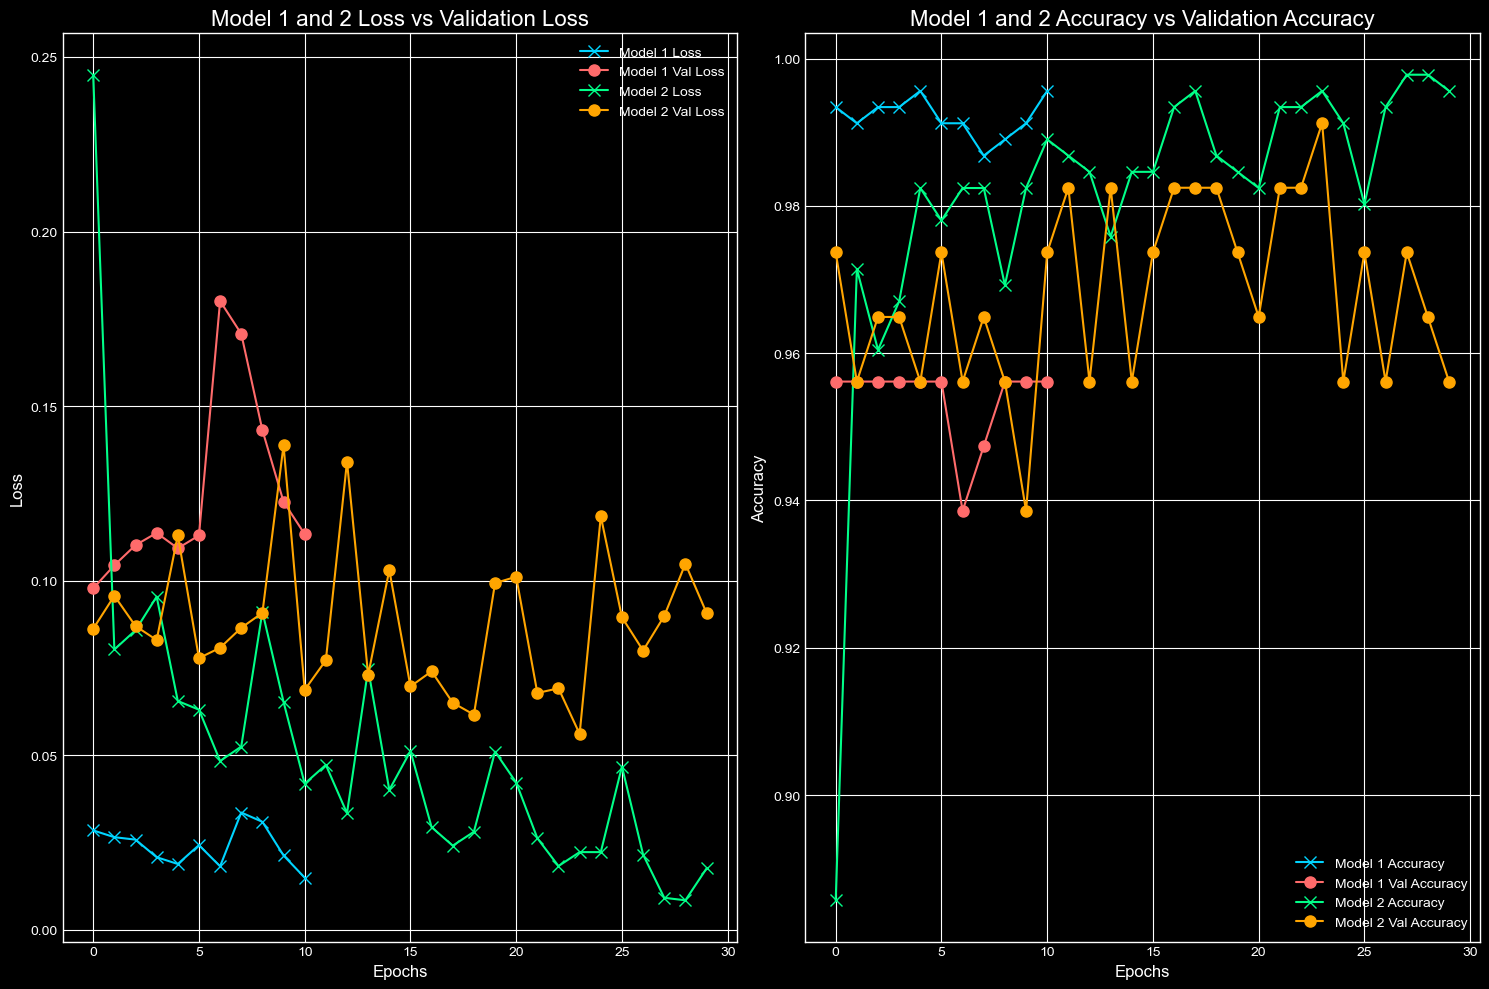

In [ ]:
plt.style.use('dark_background') # i used dark background to make the colors of the lines more visible
fig, axes = plt.subplots(1,2,figsize=(15,10))

axes[0].plot(train_data.history['loss'], label='Model 1 Loss', color='#00d4ff', marker='x',markersize=8)
axes[0].plot(train_data.history['val_loss'], label='Model 1 Val Loss', color='#ff6b6b', marker='o',markersize=8)
axes[0].plot(train_data_2.history['loss'], label='Model 2 Loss', color='#00ff88', marker='x',markersize=8)
axes[0].plot(train_data_2.history['val_loss'], label='Model 2 Val Loss', color='#ffa500', marker='o',markersize=8)
#----------------------------------------------------------------------------------------------------------------------
axes[0].legend()
axes[0].grid(True)
axes[0].set_title('Model 1 and 2 Loss vs Validation Loss', fontsize=16)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)

# -----------------------------------------------------------------------------------------------------------------------
axes[1].plot(train_data.history['accuracy'], label='Model 1 Accuracy', color='#00d4ff', marker='x',markersize=8)
axes[1].plot(train_data.history['val_accuracy'], label='Model 1 Val Accuracy', color='#ff6b6b', marker='o',markersize=8)
axes[1].plot(train_data_2.history['accuracy'], label='Model 2 Accuracy', color='#00ff88', marker='x',markersize=8)
axes[1].plot(train_data_2.history['val_accuracy'], label='Model 2 Val Accuracy', color='#ffa500', marker='o',markersize=8)
#----------------------------------------------------------------------------------------------------------------------
axes[1].legend()
axes[1].grid(True)
axes[1].set_title('Model 1 and 2 Accuracy vs Validation Accuracy', fontsize=16)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
plt.tight_layout()
plt.show()

# overall from what i see model 2 is preforming better than model 1 from what we see from the plots i made
# the loss of model 2 is slightly higher than model 1 
# however the validation loss of model 2 is lower than model 1 by lets say 0.03 which is a good improvement
# the accuracy of model 2 is higher than model 1 by around 0.01 which is a good improvement as well
# and finally the validation accuracy of model 2 and model 1 is roughly the same
# so overall model 2 is better than model 1 by adjusting the architecture epochs, activiation function and learning rates but there is always more room for improvement

TypeError: 'Axes' object is not subscriptable